# Capítulo 8 — K-Nearest Neighbors

En el cuaderno anterior usamos un clasificador sencillo para estudiar etiquetas, probabilidades y fronteras de decisión.

La práctica se centrará en tres ideas: cómo se mide la cercanía, cómo los vecinos determinan una clase y cómo cambian las decisiones al modificar el valor de `k` o la escala de las variables.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar cómo KNN clasifica un caso nuevo;
- interpretar una distancia entre puntos;
- localizar los vecinos utilizados en una predicción;
- comparar las decisiones obtenidas con distintos valores de `k`;
- comprobar por qué el escalado modifica la noción de cercanía;
- relacionar `k` con la forma de la frontera de decisión;
- reconocer ventajas y limitaciones básicas del modelo.

## 1. Importar las herramientas

Continuaremos con Wine y con la formulación binaria del cuaderno anterior. Esta vez usaremos `proline` y `color_intensity`, dos variables numéricas medidas en escalas muy diferentes.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Preparar el problema de clasificación

La pregunta será nuevamente: **¿la muestra pertenece al Cultivar 0 o a otro cultivar?** Cada fila se representará mediante la cantidad de prolina y la intensidad de color.

In [21]:
wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["cultivar"] = pd.Series(wine.target).map({
    0: "Cultivar 0",
    1: "Cultivar 1",
    2: "Cultivar 2",
})

X = df[["proline", "color_intensity"]]
y = df["cultivar"].apply(
    lambda clase: "Cultivar 0" if clase == "Cultivar 0" else "Otros"
)

pd.concat([X.head(), y.head()], axis=1)

,proline,color_intensity,cultivar
0,1065.0,5.64,Cultivar 0
1,1050.0,4.38,Cultivar 0
2,1185.0,5.68,Cultivar 0
3,1480.0,7.80,Cultivar 0
4,735.0,4.32,Cultivar 0


`X` contiene dos coordenadas para cada muestra y `y` indica su clase. En un modelo basado en distancias, cada fila puede interpretarse como un punto en un plano.

In [22]:
resumen_escalas = X.agg(["min", "max"])
resumen_escalas.loc["rango"] = resumen_escalas.loc["max"] - resumen_escalas.loc["min"]
resumen_escalas.round(2)

,proline,color_intensity
min,278.0,1.28
max,1680.0,13.00
rango,1402.0,11.72


`proline` recorre un rango superior a 1400 unidades, mientras que `color_intensity` varía en menos de 12. Esta diferencia no significa que la prolina sea necesariamente más importante. Sin escalado, sus números pueden dominar el cálculo de distancia.

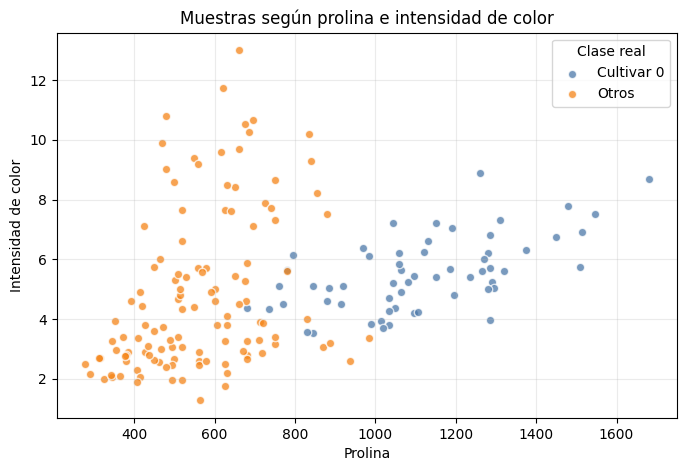

In [23]:
plt.figure(figsize=(8, 5))

colores = {"Cultivar 0": "#4C78A8", "Otros": "#F58518"}

for clase in ["Cultivar 0", "Otros"]:
    mascara = y == clase
    plt.scatter(
        X.loc[mascara, "proline"],
        X.loc[mascara, "color_intensity"],
        label=clase,
        color=colores[clase],
        alpha=0.75,
        edgecolor="white"
    )

plt.title("Muestras según prolina e intensidad de color")
plt.xlabel("Prolina")
plt.ylabel("Intensidad de color")
plt.grid(alpha=0.25)
plt.legend(title="Clase real")
plt.show()

El gráfico muestra regiones donde predominan distintas clases, pero también zonas cercanas o parcialmente mezcladas. KNN clasificará cada caso nuevo consultando las etiquetas de los puntos próximos.

## 3. Separar entrenamiento y prueba

Reservaremos el 25% de las muestras y mantendremos la distribución de clases. El escalador se ajustará después de esta separación y solamente con entrenamiento.

Esta decisión retoma lo trabajado en el capítulo anterior: separar antes de ajustar cualquier transformación evita que la información del conjunto de prueba influya en el proceso.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")

Entrenamiento: (133, 2)
Prueba:        (45, 2)


KNN conservará las 133 muestras de entrenamiento. Cuando reciba un caso nuevo, calculará su distancia respecto de esos ejemplos y buscará los más cercanos.

## 4. Un caso nuevo para clasificar

Usaremos una muestra hipotética con 700 unidades de prolina y una intensidad de color de 4,5. Está dentro de los rangos observados en el dataset.

In [25]:
muestra_nueva = pd.DataFrame({
    "proline": [700],
    "color_intensity": [4.5],
})

muestra_nueva

,proline,color_intensity
0,700,4.5


Antes de usar KNN, recordemos cómo se calcula una distancia. Para dos variables, la distancia euclidiana combina la diferencia en cada coordenada.

Tomaremos una muestra de entrenamiento y realizaremos el cálculo de manera explícita.

In [26]:
caso_ejemplo = X_train.iloc[0]

diferencia_proline = muestra_nueva.loc[0, "proline"] - caso_ejemplo["proline"]
diferencia_color = muestra_nueva.loc[0, "color_intensity"] - caso_ejemplo["color_intensity"]

distancia_euclidiana = np.sqrt(
    diferencia_proline ** 2 + diferencia_color ** 2
)

print("Caso de entrenamiento:")
print(caso_ejemplo)
print(f"\nDiferencia en prolina: {diferencia_proline:.2f}")
print(f"Diferencia en intensidad de color: {diferencia_color:.2f}")
print(f"Distancia euclidiana: {distancia_euclidiana:.2f}")

Caso de entrenamiento:
proline            1320.0
color_intensity       5.6
Name: 12, dtype: float64

Diferencia en prolina: -620.00
Diferencia en intensidad de color: -1.10
Distancia euclidiana: 620.00


La distancia combina ambas diferencias, pero la separación en prolina tiene una magnitud mucho mayor. Si repetimos este cálculo para todas las filas sin escalar, la selección de vecinos estará fuertemente condicionada por esa variable.

## 5. Buscar vecinos sin escalado

Entrenaremos un KNN con `k=5` directamente sobre los valores originales. En KNN, `.fit()` conserva la información necesaria para consultar las muestras cuando llegue una predicción.

In [27]:
knn_sin_escalar = KNeighborsClassifier(n_neighbors=5)
knn_sin_escalar.fit(X_train, y_train)

distancias_sin, posiciones_sin = knn_sin_escalar.kneighbors(muestra_nueva)

vecinos_sin_escalar = X_train.iloc[posiciones_sin[0]].copy()
vecinos_sin_escalar["clase"] = y_train.iloc[posiciones_sin[0]].values
vecinos_sin_escalar["distancia"] = distancias_sin[0]

vecinos_sin_escalar.round(3)

,proline,color_intensity,clase,distancia
135,695.0,7.10,Otros,5.636
166,695.0,10.68,Otros,7.949
100,710.0,3.30,Otros,10.072
81,714.0,3.90,Otros,14.013
69,718.0,2.85,Otros,18.075


Los cinco vecinos seleccionados sin escalado pertenecen a `Otros`. Además, sus valores de prolina quedan muy cerca de 700. La intensidad de color participa del cálculo, pero tiene mucha menos influencia numérica.

In [28]:
prediccion_sin_escalar = knn_sin_escalar.predict(muestra_nueva)[0]
print("Predicción sin escalado:", prediccion_sin_escalar)

Predicción sin escalado: Otros


Como los cinco vecinos votaron por `Otros`, esa es la clase predicha. Esta decisión es coherente con el vecindario calculado, pero la noción de cercanía está distorsionada por las escalas originales.

## 6. Escalar antes de buscar vecinos

Construiremos un pipeline que primero aplique `StandardScaler` y luego KNN. El escalador aprenderá medias y desviaciones únicamente de `X_train`.

Usamos un pipeline para encadenar la transformación y el modelo en un solo flujo. En este cuaderno, lo importante no es el pipeline en sí, sino observar cómo cambia KNN cuando las variables quedan en escalas comparables.

In [29]:
knn_escalado = Pipeline(steps=[
    ("escalador", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
])

knn_escalado.fit(X_train, y_train)

Pipeline(steps=[('escalador', StandardScaler()),
                ('knn', KNeighborsClassifier())])

Para inspeccionar los vecinos, aplicaremos a la muestra nueva el mismo escalador aprendido y consultaremos el paso KNN del pipeline.

In [30]:
escalador_ajustado = knn_escalado.named_steps["escalador"]
knn_ajustado = knn_escalado.named_steps["knn"]

muestra_nueva_escalada = escalador_ajustado.transform(muestra_nueva)
distancias_escaladas, posiciones_escaladas = knn_ajustado.kneighbors(muestra_nueva_escalada)

vecinos_escalados = X_train.iloc[posiciones_escaladas[0]].copy()
vecinos_escalados["clase"] = y_train.iloc[posiciones_escaladas[0]].values
vecinos_escalados["distancia_escalada"] = distancias_escaladas[0]

vecinos_escalados.round(3)

,proline,color_intensity,clase,distancia_escalada
65,678.0,4.60,Otros,0.084
43,680.0,4.36,Cultivar 0,0.089
98,660.0,4.50,Otros,0.132
4,735.0,4.32,Cultivar 0,0.139
21,770.0,4.50,Cultivar 0,0.230


Después del escalado, el vecindario cambió: tres de los cinco casos pertenecen a `Cultivar 0` y dos a `Otros`. Ahora ambas variables intervienen sobre escalas comparables.

Las distancias escaladas ya no están expresadas en las unidades originales. Representan diferencias después de centrar y escalar las variables.

In [31]:
prediccion_escalada = knn_escalado.predict(muestra_nueva)[0]

comparacion_escalado = pd.DataFrame({
    "preparacion": ["Sin escalado", "Con escalado"],
    "prediccion": [prediccion_sin_escalar, prediccion_escalada],
    "vecinos_Cultivar_0": [
        (vecinos_sin_escalar["clase"] == "Cultivar 0").sum(),
        (vecinos_escalados["clase"] == "Cultivar 0").sum(),
    ],
    "vecinos_Otros": [
        (vecinos_sin_escalar["clase"] == "Otros").sum(),
        (vecinos_escalados["clase"] == "Otros").sum(),
    ],
})

comparacion_escalado

,preparacion,prediccion,vecinos_Cultivar_0,vecinos_Otros
0,Sin escalado,Otros,0,5
1,Con escalado,Cultivar 0,3,2


El mismo caso recibe una predicción distinta según la preparación. El escalado no garantiza una decisión correcta, pero evita que una variable domine la distancia únicamente por la unidad en que está medida.

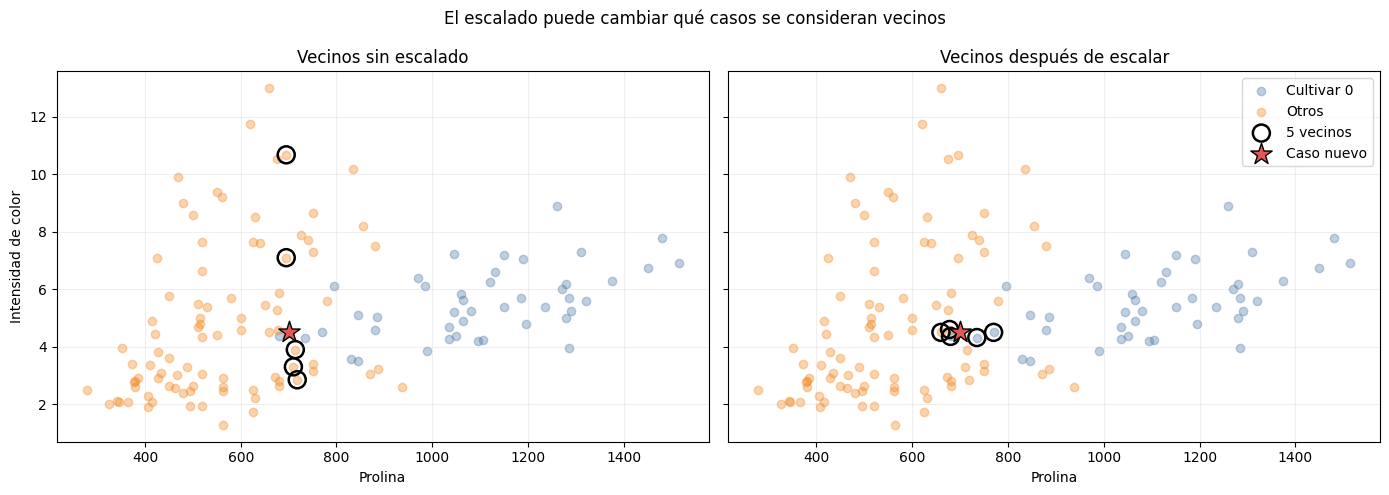

In [32]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

configuraciones = [
    (ejes[0], vecinos_sin_escalar, "Vecinos sin escalado"),
    (ejes[1], vecinos_escalados, "Vecinos después de escalar"),
]

for eje, vecinos, titulo in configuraciones:
    for clase in ["Cultivar 0", "Otros"]:
        mascara = y_train == clase
        eje.scatter(
            X_train.loc[mascara, "proline"],
            X_train.loc[mascara, "color_intensity"],
            color=colores[clase],
            alpha=0.35,
            label=clase
        )

    eje.scatter(
        vecinos["proline"],
        vecinos["color_intensity"],
        facecolors="none",
        edgecolors="black",
        s=150,
        linewidths=1.8,
        label="5 vecinos"
    )
    eje.scatter(
        muestra_nueva.loc[0, "proline"],
        muestra_nueva.loc[0, "color_intensity"],
        marker="*",
        s=260,
        color="#E45756",
        edgecolor="black",
        label="Caso nuevo"
    )
    eje.set_title(titulo)
    eje.set_xlabel("Prolina")
    eje.grid(alpha=0.2)

ejes[0].set_ylabel("Intensidad de color")
ejes[1].legend(loc="best")
plt.suptitle("El escalado puede cambiar qué casos se consideran vecinos")
plt.tight_layout()
plt.show()

Los puntos del dataset son los mismos en ambos paneles. Lo que cambia son los cinco casos rodeados en negro. El escalado modifica la distancia y, por lo tanto, modifica el vecindario utilizado para votar.

## 7. Comprobar la votación de KNN

Con `k=5`, cada vecino aporta un voto. La clase mayoritaria se convierte en la predicción. Además, `scikit-learn` puede mostrar la proporción de vecinos de cada clase como una probabilidad estimada por KNN.

In [33]:
probabilidades_k5 = knn_escalado.predict_proba(muestra_nueva)[0]

votacion_k5 = pd.DataFrame({
    "clase": knn_escalado.classes_,
    "cantidad_vecinos": [
        (vecinos_escalados["clase"] == clase).sum()
        for clase in knn_escalado.classes_
    ],
    "proporcion": probabilidades_k5,
})

votacion_k5

,clase,cantidad_vecinos,proporcion
0,Cultivar 0,3,0.6
1,Otros,2,0.4


Tres de los cinco vecinos pertenecen a `Cultivar 0`, por lo que su proporción es 0,6. Los otros dos representan 0,4. KNN elige la clase con más votos.

Esta proporción describe el vecindario consultado; no debe confundirse automáticamente con una probabilidad real perfectamente calibrada.

## 8. Comparar distintos valores de `k`

Entrenaremos tres pipelines idénticos salvo por la cantidad de vecinos: `k=1`, `k=5` y `k=25`. Todos usarán el mismo conjunto de entrenamiento y el mismo escalado.

In [34]:
valores_k = [1, 5, 25]
modelos_k = {}
resultados_k = []

for k in valores_k:
    modelo = Pipeline(steps=[
        ("escalador", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    modelo.fit(X_train, y_train)
    modelos_k[k] = modelo

    probabilidades = modelo.predict_proba(muestra_nueva)[0]
    indice_cultivar = list(modelo.classes_).index("Cultivar 0")

    resultados_k.append({
        "k": k,
        "clase_predicha": modelo.predict(muestra_nueva)[0],
        "prob_Cultivar_0": probabilidades[indice_cultivar],
        "prob_Otros": 1 - probabilidades[indice_cultivar],
    })

pd.DataFrame(resultados_k).round(3)

,k,clase_predicha,prob_Cultivar_0,prob_Otros
0,1,Otros,0.00,1.00
1,5,Cultivar 0,0.60,0.40
2,25,Otros,0.28,0.72


El caso nuevo cambia de clase al modificar `k`. Con `k=1`, el único vecino pertenece a `Otros`. Con `k=5`, la mayoría local favorece a `Cultivar 0`. Con `k=25`, el entorno es más amplio y vuelve a predominar `Otros`.

No existe un valor de `k` universalmente correcto. Elegirlo requiere una evaluación adecuada; en este cuaderno nos limitamos a observar cómo cambia el comportamiento.

## 9. Comparar fronteras de decisión

El valor de `k` también modifica las regiones donde KNN predice cada clase. Dibujaremos las fronteras de los tres modelos escalados.

In [35]:
proline_min, proline_max = X["proline"].min() - 50, X["proline"].max() + 50
color_min, color_max = X["color_intensity"].min() - 0.5, X["color_intensity"].max() + 0.5

malla_proline, malla_color = np.meshgrid(
    np.linspace(proline_min, proline_max, 260),
    np.linspace(color_min, color_max, 260)
)

puntos_malla = pd.DataFrame({
    "proline": malla_proline.ravel(),
    "color_intensity": malla_color.ravel(),
})

mapa_fondo = ListedColormap(["#B9D5EA", "#F8D1AA"])

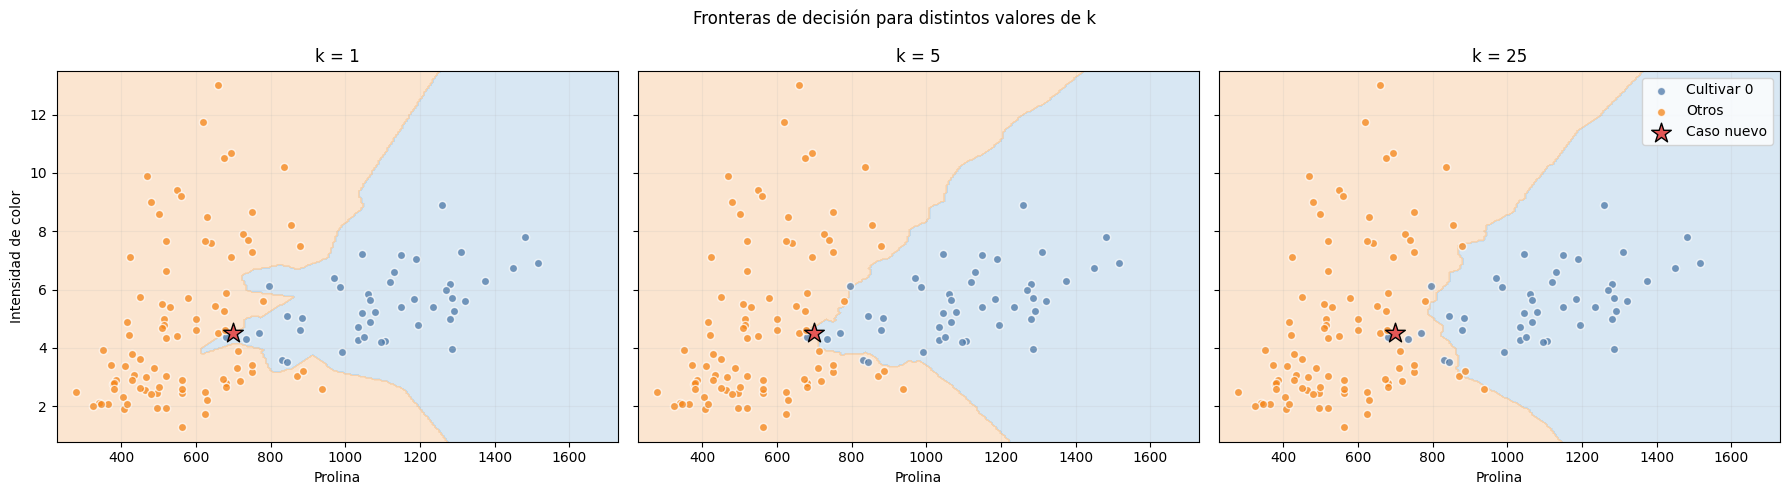

In [36]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for eje, k in zip(ejes, valores_k):
    clases_malla = modelos_k[k].predict(puntos_malla)
    regiones = pd.Series(clases_malla).map({"Cultivar 0": 0, "Otros": 1}).to_numpy()
    regiones = regiones.reshape(malla_proline.shape)

    eje.contourf(
        malla_proline,
        malla_color,
        regiones,
        alpha=0.55,
        cmap=mapa_fondo
    )

    for clase in ["Cultivar 0", "Otros"]:
        mascara = y_train == clase
        eje.scatter(
            X_train.loc[mascara, "proline"],
            X_train.loc[mascara, "color_intensity"],
            color=colores[clase],
            label=clase,
            alpha=0.75,
            edgecolor="white",
            s=35
        )

    eje.scatter(
        muestra_nueva.loc[0, "proline"],
        muestra_nueva.loc[0, "color_intensity"],
        marker="*",
        s=220,
        color="#E45756",
        edgecolor="black",
        label="Caso nuevo"
    )
    eje.set_title(f"k = {k}")
    eje.set_xlabel("Prolina")
    eje.grid(alpha=0.15)

ejes[0].set_ylabel("Intensidad de color")
ejes[-1].legend(loc="best")
plt.suptitle("Fronteras de decisión para distintos valores de k")
plt.tight_layout()
plt.show()

Con `k=1`, la frontera es muy irregular y responde a casos individuales. Con `k=5`, pequeñas irregularidades se suavizan. Con `k=25`, las regiones son más generales y pueden perder detalles locales.

Un `k` pequeño puede ser sensible al ruido; uno demasiado grande puede favorecer patrones generales o la clase mayoritaria. La elección busca un equilibrio entre ambos extremos.

## 10. Ventajas y limitaciones observadas

La práctica permite resumir algunas características del modelo.

In [37]:
resumen_knn = pd.DataFrame({
    "aspecto": [
        "Interpretación",
        "Forma de la frontera",
        "Escalado",
        "Valor de k",
        "Predicción",
        "Muchas variables",
    ],
    "observacion": [
        "La decisión puede explicarse mirando vecinos concretos.",
        "Puede adaptarse a patrones locales y no lineales.",
        "Es fundamental porque el modelo depende de distancias.",
        "Controla cuán local o general resulta la decisión.",
        "Debe buscar vecinos entre los datos conservados.",
        "Las distancias pueden volverse menos informativas.",
    ]
})

resumen_knn

,aspecto,observacion
0,Interpretación,La decisión puede explicarse mirando vecinos c...
1,Forma de la frontera,Puede adaptarse a patrones locales y no lineales.
2,Escalado,Es fundamental porque el modelo depende de dis...
3,Valor de k,Controla cuán local o general resulta la decis...
4,Predicción,Debe buscar vecinos entre los datos conservados.
5,Muchas variables,Las distancias pueden volverse menos informati...


KNN resulta intuitivo y flexible, pero depende completamente de que la cercanía represente una semejanza útil. Variables irrelevantes, escalas incorrectas, ruido o demasiadas dimensiones pueden deteriorar sus decisiones.

Además, conserva los datos de entrenamiento y debe consultarlos al predecir. Esto puede resultar costoso cuando el dataset es muy grande.

## Actividad breve

Modificá `k_actividad` usando un número impar positivo y cambiá las coordenadas de `muestra_actividad`. Podés guiarte por rangos aproximados del gráfico: prolina entre 250 y 1700, e intensidad de color entre 1 y 13.

Antes de ejecutar, ubicá el punto en los gráficos y anticipá qué clase podrían votar sus vecinos.

Mantené los mismos nombres de columnas: `proline` y `color_intensity`.

In [38]:
k_actividad = 7

muestra_actividad = pd.DataFrame({
    "proline": [850],
    "color_intensity": [5.5],
})

modelo_actividad = Pipeline(steps=[
    ("escalador", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k_actividad)),
])

modelo_actividad.fit(X_train, y_train)

prediccion_actividad = modelo_actividad.predict(muestra_actividad)[0]
probabilidades_actividad = modelo_actividad.predict_proba(muestra_actividad)[0]

print("Clase predicha:", prediccion_actividad)
for clase, probabilidad in zip(modelo_actividad.classes_, probabilidades_actividad):
    print(f"Proporción de vecinos de {clase}: {probabilidad:.3f}")

Clase predicha: Cultivar 0
Proporción de vecinos de Cultivar 0: 0.857
Proporción de vecinos de Otros: 0.143


Al modificar el punto o `k`, puede cambiar el vecindario y, con él, la predicción. Usar un valor impar reduce la posibilidad de empate en clasificación binaria, aunque no reemplaza la necesidad de evaluar qué configuración resulta adecuada.

## Cierre del cuaderno

En este cuaderno abrimos la lógica de KNN. Para clasificar un caso nuevo, el modelo mide su distancia a los ejemplos de entrenamiento, selecciona los `k` más cercanos y asigna la clase mayoritaria.

Comprobamos que el escalado puede cambiar qué casos se consideran vecinos. También observamos que `k` controla el alcance de la votación: valores pequeños producen decisiones muy locales y sensibles; valores grandes ofrecen mayor estabilidad, pero pueden borrar detalles importantes.

KNN puede ser una buena opción cuando los casos parecidos tienden a compartir clase, las variables representan bien esa semejanza y el tamaño del dataset permite buscar vecinos. Su simplicidad no elimina la necesidad de preparar los datos y evaluar cuidadosamente sus decisiones.

## Para pensar

Antes de continuar, respondé con tus propias palabras:

1. ¿Qué representa cada fila de `X` desde el punto de vista de KNN?
2. ¿Cómo usa el modelo las distancias para producir una predicción?
3. ¿Por qué el caso nuevo tuvo vecinos diferentes antes y después del escalado?
4. ¿Qué ventajas y riesgos presenta usar `k=1`?
5. ¿Qué puede ocurrir si `k` es demasiado grande?
6. ¿En qué situaciones la idea de cercanía podría no ser útil para clasificar?